In [641]:
import numpy as numpy
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [642]:
df_train = pd.read_csv('../data/train.csv')


In [643]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [644]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [645]:
df_train.shape

(891, 12)

In [646]:
df_train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [647]:
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())

In [648]:
df_train[df_train['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [649]:
df_train['Embarked']=df_train['Embarked'].fillna(df_train['Embarked'].mode())

In [650]:
df_train['Age']=df_train['Age'].astype(int)

In [651]:
df_train = df_train.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1)

In [652]:
df_train.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.345679,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.028212,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [653]:
df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\simoen\AppData\Local\Temp\ipykernel_1304\1220814546.py:1: SyntaxWarning: invalid escape sequence '\.'
  df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [654]:
df_train=pd.get_dummies(df_train,drop_first=True)

In [655]:

def Explore(col):
    Q1 = df_train[col].quantile(0.25)
    Q2 = df_train[col].quantile(0.5)
    Q3 = df_train[col].quantile(0.75)
    max = df_train[col].max()
    number_of_survived_Q1_M = df_train[(df_train[col]<=Q1) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == True)].shape[0]
    number_of_survived_Q1_F = df_train[(df_train[col]<=Q1) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == False)].shape[0]
    number_of_not_survived_Q1_M = df_train[(df_train[col]<=Q1) & (df_train['Survived'] == 0)&(df_train['Sex_male'] == True)].shape[0]
    number_of_not_survived_Q1_F = df_train[(df_train[col]<=Q1) & (df_train['Survived'] == 0)&(df_train['Sex_male'] == False)].shape[0]
    number_of_survived_Q2_M = df_train[(df_train[col]>Q1) & (df_train[col]<=Q2) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == True)].shape[0]
    number_of_survived_Q2_F = df_train[(df_train[col]>Q1) & (df_train[col]<=Q2) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == False)].shape[0]
    number_of_not_survived_Q2_M = df_train[(df_train[col]>Q1) & (df_train[col]<=Q2) & (df_train['Survived'] == 0)&(df_train['Sex_male'] == True)].shape[0]
    number_of_not_survived_Q2_F = df_train[(df_train[col]>Q1) & (df_train[col]<=Q2) & (df_train['Survived'] == 0)&(df_train['Sex_male'] == False)].shape[0]
    number_of_survived_Q3_M = df_train[(df_train[col]>Q2) & (df_train[col]<=Q3) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == True)].shape[0]
    number_of_survived_Q3_F = df_train[(df_train[col]>Q2) & (df_train[col]<=Q3) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == False)].shape[0]
    number_of_not_survived_Q3_M = df_train[(df_train[col]>Q2) & (df_train[col]<=Q3) & (df_train['Survived'] == 0)&(df_train['Sex_male'] == True)].shape[0]
    number_of_not_survived_Q3_F = df_train[(df_train[col]>Q2) & (df_train[col]<=Q3) & (df_train['Survived'] == 0)&(df_train['Sex_male'] == False)].shape[0]
    number_of_survived_max_M = df_train[(df_train[col]>Q3) & (df_train[col]<=max) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == True)].shape[0]
    number_of_survived_max_F = df_train[(df_train[col]>Q3) & (df_train[col]<=max) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == False)].shape[0]
    number_of_not_survived_max_M = df_train[(df_train[col]>Q3) & (df_train[col]<=max) & (df_train['Survived'] == 0)&(df_train['Sex_male'] == True)].shape[0]
    number_of_not_survived_max_F = df_train[(df_train[col]>Q3) & (df_train[col]<=max) & (df_train['Survived'] == 0)&(df_train['Sex_male'] == False)].shape[0]
    data = {
        'Range': [f'less than {Q1}', f'between {Q1} and {Q2}', f'between {Q2} and {Q3}', f'greater than {Q3}'],
        'Male_Survived': [number_of_survived_Q1_M, number_of_survived_Q2_M, number_of_survived_Q3_M, number_of_survived_max_M],
        'Male_Not_Survived': [number_of_not_survived_Q1_M, number_of_not_survived_Q2_M, number_of_not_survived_Q3_M, number_of_not_survived_max_M],
        'Female_Survived': [number_of_survived_Q1_F, number_of_survived_Q2_F, number_of_survived_Q3_F, number_of_survived_max_F],
        'Female_Not_Survived': [number_of_not_survived_Q1_F, number_of_not_survived_Q2_F, number_of_not_survived_Q3_F, number_of_not_survived_max_F]
    }
   
    new_df = pd.DataFrame(data)
    return new_df

In [656]:
Explore('Pclass')

,Range,Male_Survived,Male_Not_Survived,Female_Survived,Female_Not_Survived
0,less than 2.0,62,168,161,9
1,between 2.0 and 3.0,47,300,72,72
2,between 3.0 and 3.0,0,0,0,0
3,greater than 3.0,0,0,0,0


In [657]:
Explore('Age')

,Range,Male_Survived,Male_Not_Survived,Female_Survived,Female_Not_Survived
0,less than 22.0,31,104,67,29
1,between 22.0 and 28.0,33,180,69,28
2,between 28.0 and 35.0,19,66,40,8
3,greater than 35.0,26,118,57,16


In [658]:
Explore('Fare')

,Range,Male_Survived,Male_Not_Survived,Female_Survived,Female_Not_Survived
0,less than 7.9104,14,166,30,13
1,between 7.9104 and 14.4542,25,132,43,24
2,between 14.4542 and 31.0,36,93,65,28
3,greater than 31.0,34,77,95,16


In [659]:
df_train['fare_bin'] = pd.qcut(df_train['Fare'], q=4, labels=False)

In [660]:
df_train['family']=df_train['SibSp']+df_train['Parch']

In [661]:
df_train['Age_bin'] = pd.qcut(df_train['Age'], q=4, labels=False)

In [662]:
df_train['Alone'] = (df_train['SibSp'] == 0)&(df_train['Parch'] == 0)

In [664]:
x_train = df_train.drop('Survived', axis=1)
y_train = df_train['Survived']
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score,precision_score, recall_score
from sklearn.model_selection import GridSearchCV
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.2, random_state=42)


In [665]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [682]:
model_lr = LogisticRegression()
model_lr.fit(x_train_scaled, y_train)
y_pred_lr = model_lr.predict(x_test_scaled)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression F1 Score:", f1_score(y_test, y_pred_lr))
rint("Logistic Regression Precision Score:", precision_score(y_test, y_pred_lr))
print("Logistic Regression Recall Score:", recall_score(y_test, y_pred_lr))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

param_grid = {
        'learning_rate': [0.01, 0.1, 0.2],
        'n_estimators': [100, 200, 500],
        'max_depth': [3, 5, 7]
    }
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                              subsample=0.8, colsample_bytree=0.8, gamma=0.1, reg_alpha=0.1, reg_lambda=1)
grid_search = GridSearchCV(model_xgb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train_scaled, y_train)
model_xgb = grid_search.best_estimator_
y_pred_xgb = model_xgb.predict(x_test_scaled)
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost F1 Score:", f1_score(y_test, y_pred_xgb))
print("XGBoost Precision Score:", precision_score(y_test, y_pred_xgb))
print("XGBoost Recall Score:", recall_score(y_test, y_pred_xgb))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Logistic Regression Confusion Matrix:
[[90 15]
 [19 55]]
Logistic Regression Accuracy: 0.8100558659217877
Logistic Regression F1 Score: 0.7638888888888888


TypeError: return arrays must be of ArrayType

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Logistic Regression Confusion Matrix:
[[90 15]
 [19 55]]
Logistic Regression Accuracy: 0.8100558659217877
Logistic Regression F1 Score: 0.7638888888888888
Logistic Regression Precision Score: 0.7857142857142857
Logistic Regression Recall Score: 0.7432432432432432


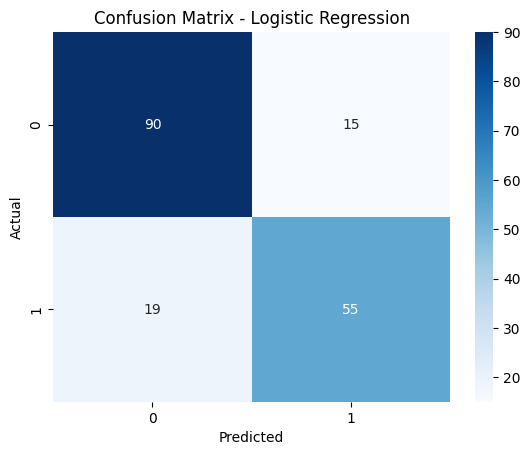

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

XGBoost Confusion Matrix:
[[91 14]
 [20 54]]
XGBoost Accuracy: 0.8100558659217877
XGBoost F1 Score: 0.7605633802816901
XGBoost Precision Score: 0.7941176470588235
XGBoost Recall Score: 0.7297297297297297


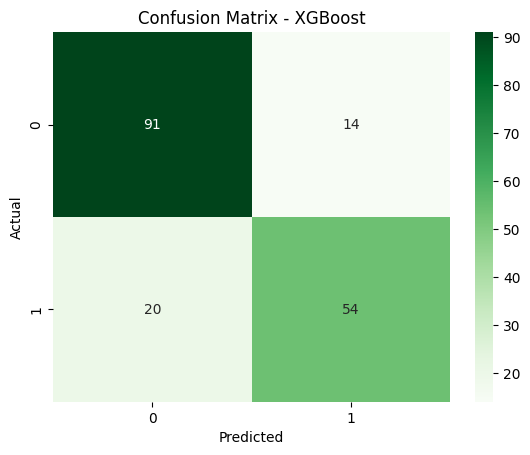

In [667]:
run_model(expert1)

In [668]:
df_test = pd.read_csv('../data/test.csv')
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [669]:
df_test['Age'] = df_test['Age'].fillna(df_test['Age'].median())

In [670]:
df_test['Embarked']=df_test['Embarked'].fillna(df_test['Embarked'].mode())

In [671]:
df_test['Age']=df_test['Age'].astype(int)

In [672]:
df_test = df_test.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1)

In [673]:
df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\simoen\AppData\Local\Temp\ipykernel_1304\569521743.py:1: SyntaxWarning: invalid escape sequence '\.'
  df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [674]:
df_test=pd.get_dummies(df_test,drop_first=True)

In [675]:
df_test['fare_bin'] = pd.qcut(df_test['Fare'], q=4, labels=False)

In [676]:
df_test['family']=df_test['SibSp']+df_test['Parch']

In [677]:
df_test['Age_bin'] = pd.qcut(df_test['Age'], q=4, labels=False)

In [678]:
df_test['Alone'] = (df_test['SibSp'] == 0)&(df_test['Parch'] == 0)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Logistic Regression Confusion Matrix:
[[90 15]
 [19 55]]
Logistic Regression Accuracy: 0.8100558659217877
Logistic Regression F1 Score: 0.7638888888888888
Logistic Regression Precision Score: 0.7857142857142857
Logistic Regression Recall Score: 0.7432432432432432


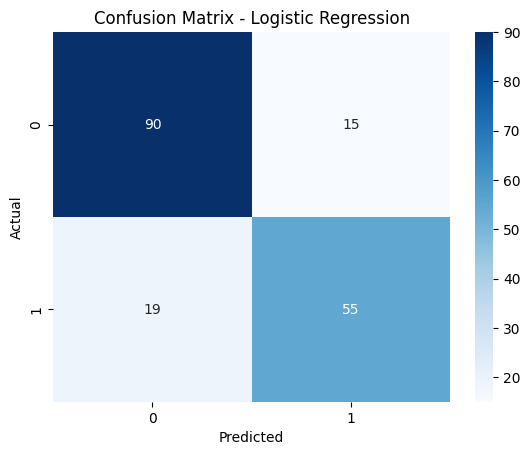

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

XGBoost Confusion Matrix:
[[91 14]
 [20 54]]
XGBoost Accuracy: 0.8100558659217877
XGBoost F1 Score: 0.7605633802816901
XGBoost Precision Score: 0.7941176470588235
XGBoost Recall Score: 0.7297297297297297


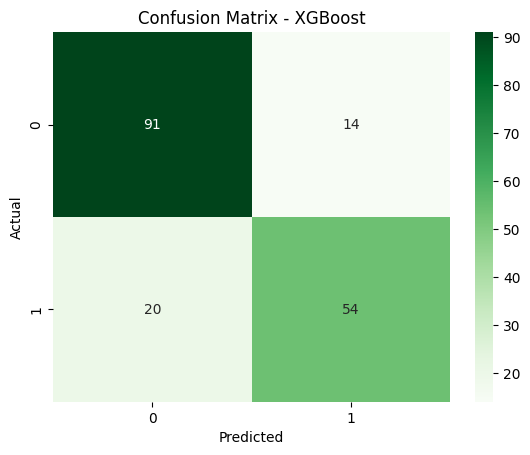

In [679]:
# Align df_test columns with x_train columns
df = df_test.reindex(columns=x_train.columns, fill_value=0)

# Now scale the aligned test data
df_test_scaled = scaler.transform(df)
predictions = run_model(df_test_scaled)


In [680]:
submission = pd.DataFrame({
    'PassengerId':pd.read_csv('../data/test.csv')['PassengerId'],
    'Survived': predictions
})
submission.to_csv('submission.csv', index=False)